##Refatoração: De NumPy para PyTorch (Tensores)
Autor: Leandro Belo de Almeida Gomes

Objetivo: Converter o script utilizado no *"Estudo de caso 01: Fundamentos da Classificação Linear"* em um código que utiliza a estrutura real do PyTorch.

##1. Instalção das bibliotecas PyTorch e Matplotlib

In [1]:
### Aqui é realizado a troca do NumPy para torch.Tensor para demonstração de como
### redes em Deep Learning operam.
import torch
import matplotlib.pyplot as plt

# Fixar a Seed para garantir que o resultado seja o mesmo sempre.
torch.manual_seed(42)

##2. Definição do dispositivo (Consciência de Hardware)

In [2]:
#Verificação de disponibilidade de GPU com suporte CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

##3. Parâmetros do Modelo (Tensores)

In [3]:
# Em PyTorch, pesos e viés são tratados como vetores/matrizes
w = torch.tensor([-1.0, 4.0], device=device) # Pesos 'a' e 'b'
b = torch.tensor([0.4], device=device) # Viés 'c'

##4. Dados de entrada (Pontos convertidos para Tensores)

In [4]:
pontos = torch.tensor([
    [2.0, 0.4],   # Ponto 1 (Azul)
    [1.0, 0.6],   # Ponto 2 (Vermelho)
    [3.0, -0.4]   # Ponto 3 (Verde)
], device=device)

##5. Cálculo de ativação (Operação de Matriz)

In [5]:
#Com está função é possível economizar memória durante a inferência
with torch.no_grad():
    retornos = torch.matmul(pontos, w) + b

## 6, Exibição dos resultados

Ponto 1: Retorno 0.00 -> Acima da reta
Ponto 2: Retorno 1.80 -> Acima da reta
Ponto 3: Retorno -4.20 -> Abaixo da reta


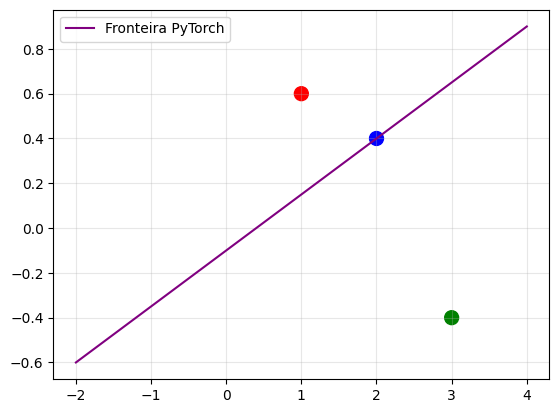

In [6]:
for i, ret in enumerate(retornos):
    classe = "Acima" if ret > 0 else "Abaixo"
    print(f"Ponto {i+1}: Retorno {ret.item():.2f} -> {classe} da reta")

# Visualização (Convertendo de volta para numpy apenas para o gráfico)
def plot_pytorch_frontier(w, b):
    x_val = torch.linspace(-2, 4, 50)
    # Isolando y: y = (-w[0]*x - b) / w[1]
    y_val = (-w[0] * x_val - b) / w[1]

    plt.plot(x_val.numpy(), y_val.numpy(), label='Fronteira PyTorch', color='purple')
    plt.scatter(pontos.cpu()[:, 0], pontos.cpu()[:, 1], c=['blue', 'red', 'green'], s=100)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

plot_pytorch_frontier(w, b)

No script original, cada ponto era calculado manualmente ($ret1, ret2$ e $ret3$). No PyTorch, é utilizado o torch.matmul (multiplicação de matrizes) para processar todos os pontos simultaneamente, o que permite o processamento de milhões de dados por segundo.

Como o objetivo é apenas validar a reta e não treinar o modelo, desativei o rastreamento de gradientes. Isso reduz drasticamente o consumo de memória.

Após esta refatoração, o código detecta automaticamente se há uma GPU disponível (CUDA), garantindo uma performance superior.